# Spindown, 2026-09-08

First rotational free decay with a recorded start time. Drive off at **front-end GPS 1472934149**.

**The question this notebook exists to answer:** is the decay *exponential* (viscous drag, torque ∝ ω) or *linear* (constant retarding torque)? A quick six-point fit yesterday gave τ ≈ 37 min for the exponential and −0.0685 mHz/s for the linear, with the linear marginally better — but six points over a 25% decay cannot separate them.

It matters a great deal for how fast the rotor can eventually be driven:

| | drag at 15 Hz | terminal speed |
|---|---|---|
| viscous | 0.91 × stator torque | ~16.5 Hz |
| constant torque | 0.009 × | no drag limit |

**Two methodological choices, both learned the hard way on 08-09:**

1. **Use `LES_YAW_IN1_DQ`, not `OUT_DQ`.** `IN1_DQ` is tapped upstream of the input switch, gain and output switch, so it recorded faithfully through the model restart and all the switch changes. `OUT_DQ` was intermittently dead. Yesterday's analysis used `OUT_DQ`.
2. **Never take the loudest spectral peak as the frequency.** This signal is strongly non-sinusoidal — at large libration amplitude the 3rd harmonic was *stronger* than the fundamental, which produced a bogus "0.71 Hz" reading and, earlier, a stiffness measurement that was pure noise. Here we fit a chosen line explicitly and check for sub-harmonics.

In [1]:
import numpy as np, matplotlib.pyplot as plt

d = np.load('spindown_20260908_raw.npz')
les, drv, fs = d['les'], d['drv'], float(d['fs'])
GPS0, STOP = int(d['gps_start']), int(d['stop'])
t = GPS0 + np.arange(len(les))/fs - STOP     # seconds relative to drive-off
print(f'{len(les)/fs:.0f} s of data, t = {t[0]:.0f} .. {t[-1]:.0f} s relative to drive-off')

1600 s of data, t = -700 .. 900 s relative to drive-off


## 1. Where does the drive actually stop?

Sanity check before anything else — `V2_OUT_DQ` should go quiet at t = 0.

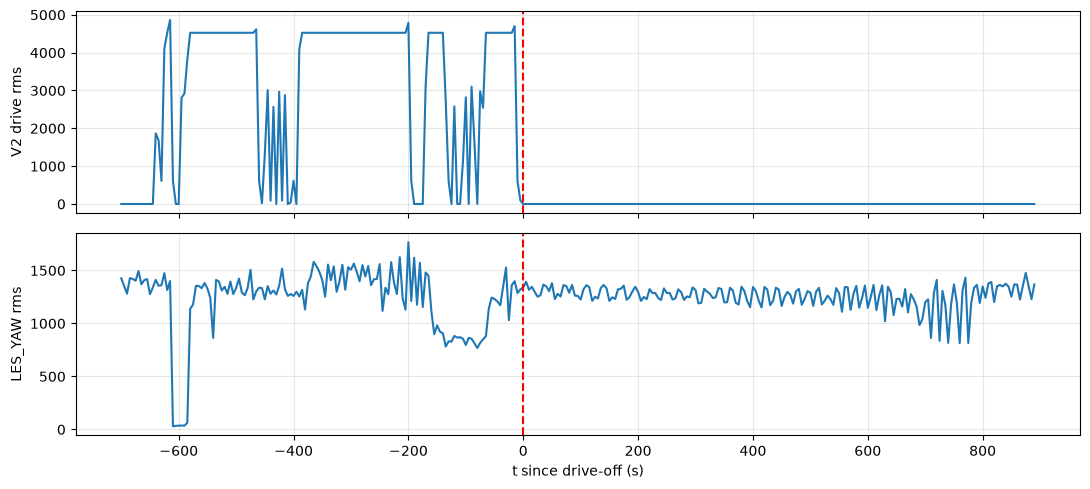

drive rms after t=20 s: max 0.0  (should be ~0)


In [2]:
blk = int(5*fs)
tb = np.array([t[i] for i in range(0, len(t)-blk, blk)])
drms = np.array([drv[i:i+blk].std() for i in range(0, len(drv)-blk, blk)])
lrms = np.array([les[i:i+blk].std() for i in range(0, len(les)-blk, blk)])

fig, ax = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
ax[0].plot(tb, drms); ax[0].set_ylabel('V2 drive rms'); ax[0].axvline(0, color='r', ls='--')
ax[1].plot(tb, lrms); ax[1].set_ylabel('LES_YAW rms'); ax[1].axvline(0, color='r', ls='--')
ax[1].set_xlabel('t since drive-off (s)')
for a in ax: a.grid(alpha=.3)
plt.tight_layout(); plt.show()

after = drms[tb > 20]
print(f'drive rms after t=20 s: max {after.max():.1f}  (should be ~0)')

## 2. Spectrogram — see the rotation line and where it dies

Look at the whole thing before fitting anything. The rotation shows as a 1×/2×/3× harmonic series that slides downward; when it breaks up, the rotor has been captured into libration and the spindown is over.

/tmp/ipykernel_1284892/1257109927.py:1: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.6)
  from scipy.signal import spectrogram


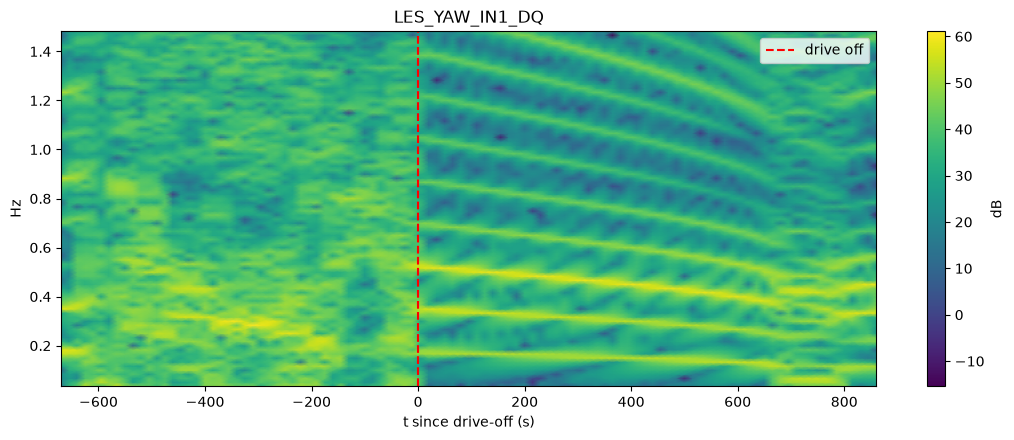

In [3]:
from scipy.signal import spectrogram
f, tsp, Sxx = spectrogram(les - les.mean(), fs=fs, nperseg=int(60*fs),
                          noverlap=int(45*fs), scaling='spectrum')
m = (f > 0.03) & (f < 1.5)
plt.figure(figsize=(11, 4.5))
plt.pcolormesh(tsp + t[0], f[m], 10*np.log10(Sxx[m]+1e-12), shading='gouraud')
plt.axvline(0, color='r', ls='--', label='drive off')
plt.ylabel('Hz'); plt.xlabel('t since drive-off (s)'); plt.colorbar(label='dB')
plt.legend(); plt.title('LES_YAW_IN1_DQ'); plt.tight_layout(); plt.show()

## 3. Track the rotation frequency

Tracked on the **3× line** and divided by 3 — better frequency resolution than the fundamental for the same window, and it was the strongest line while rotating.

Each estimate: window the block, FFT, find the peak within a band that *follows* the previous estimate (so it cannot jump to a neighbouring harmonic), then parabolic-interpolate for sub-bin precision. The `guard` check flags any step larger than physically plausible.

In [4]:
def peak_in_band(x, fs, lo, hi):
    ac = x - x.mean()
    X = np.abs(np.fft.rfft(ac*np.hanning(len(ac))))
    fr = np.fft.rfftfreq(len(ac), 1/fs)
    m = (fr > lo) & (fr < hi)
    if not m.any(): return np.nan, 0.0
    i = np.flatnonzero(m)[np.argmax(X[m])]
    y0, y1, y2 = X[i-1], X[i], X[i+1]
    den = y0 - 2*y1 + y2
    fpk = fr[i] + (0.5*(y0-y2)/den if den else 0)*(fr[1]-fr[0])
    lo_i, hi_i = max(0, i-60), i+60
    snr = X[i]/(np.median(X[lo_i:hi_i]) or 1)
    return fpk, snr

WIN = 90.0                      # s per estimate
STEP = 30.0                     # s between estimates (overlapping)
n, s = int(WIN*fs), int(STEP*fs)
rows = []
track = 0.52                    # starting guess for the 3x line, Hz
for i in range(0, len(les)-n, s):
    tc = t[i] + WIN/2
    if tc < 5: continue         # skip the driven period
    f3, snr = peak_in_band(les[i:i+n], fs, track*0.75, track*1.25)
    if np.isnan(f3): continue
    rows.append((tc, f3, f3/3, snr, les[i:i+n].std()))
    track = f3                  # follow it

T   = np.array([r[0] for r in rows]); F3  = np.array([r[1] for r in rows])
FR  = np.array([r[2] for r in rows]); SNR = np.array([r[3] for r in rows])
RMS = np.array([r[4] for r in rows])
print(f'{"t (s)":>8} {"3x (Hz)":>9} {"rotor":>9} {"SNR":>8} {"rms":>8}')
for r in rows: print(f'{r[0]:8.0f} {r[1]:9.4f} {r[2]:9.5f} {r[3]:8.1f} {r[4]:8.0f}')

   t (s)   3x (Hz)     rotor      SNR      rms
       5    0.5229   0.17432     16.0     1358
      35    0.5187   0.17290    331.3     1327
      65    0.5125   0.17085    323.4     1314
      95    0.5081   0.16938    251.6     1310
     125    0.5015   0.16716    338.4     1305
     155    0.4972   0.16572    293.5     1306
     185    0.4907   0.16356    255.8     1302
     215    0.4865   0.16217    257.2     1297
     245    0.4798   0.15995    277.9     1289
     275    0.4754   0.15845    200.5     1286
     305    0.4684   0.15614    265.4     1289
     335    0.4637   0.15457    245.2     1280
     365    0.4568   0.15228    198.7     1287
     395    0.4516   0.15054    187.7     1272
     425    0.4447   0.14824    214.4     1283
     455    0.4376   0.14587    149.6     1274
     485    0.4314   0.14380    174.8     1275
     515    0.4232   0.14107    185.6     1265
     545    0.4155   0.13849    164.8     1266
     575    0.4082   0.13605    141.9     1268
     605    0

## 4. Where is the data trustworthy?

Drop points where the line has lost SNR — past the capture into libration the tracker will happily report a plausible-looking number that means nothing. That is exactly what `track_spindown.py` did yesterday after t ≈ 700 s.

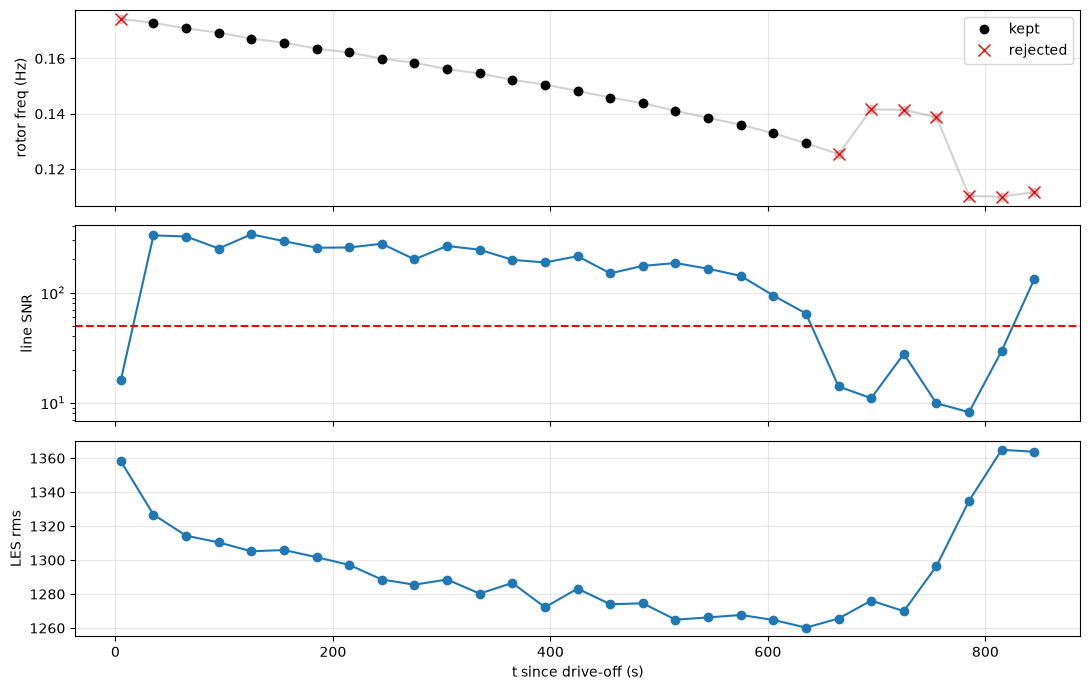

21 of 29 points kept, t = 35..635 s
frequency 0.1729 -> 0.1293 Hz  (25.2% decay)


In [5]:
# Two rejection criteria, and the second is the important one.
#
#   SNR       -- once the rotation line dies the tracker still returns a
#                plausible number from whatever is loudest in the band.
#   MONOTONIC -- a FREELY DECAYING rotor cannot speed up. Any upward step is
#                proof the tracker has lost the line, and it is a sharper
#                discriminator than SNR alone: at t=695 the naive tracker
#                reported 0.4247 Hz after 0.3762, a 13% jump UP, physically
#                impossible and caught only by this test.
#
# Note the FIRST point (t=5) legitimately has low SNR -- it straddles the
# drive-off transition -- so we skip leading bad points rather than stopping.
SNR_MIN = 50.0

good = np.zeros(len(FR), bool)
start = np.argmax(SNR > SNR_MIN)          # first index above threshold
runmin = np.inf
for k in range(start, len(FR)):
    if SNR[k] <= SNR_MIN:                 # line lost
        break
    if FR[k] > runmin*1.02:               # sped up -> tracker lost it
        break
    good[k] = True
    runmin = min(runmin, FR[k])

fig, ax = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
ax[0].plot(T, FR, 'o-', alpha=.35, color='gray')
ax[0].plot(T[good], FR[good], 'ko', label='kept')
ax[0].plot(T[~good], FR[~good], 'rx', ms=9, label='rejected')
ax[0].set_ylabel('rotor freq (Hz)'); ax[0].legend()
ax[1].semilogy(T, SNR, 'o-'); ax[1].axhline(SNR_MIN, color='r', ls='--'); ax[1].set_ylabel('line SNR')
ax[2].plot(T, RMS, 'o-'); ax[2].set_ylabel('LES rms'); ax[2].set_xlabel('t since drive-off (s)')
for a in ax: a.grid(alpha=.3)
plt.tight_layout(); plt.show()
print(f'{good.sum()} of {len(good)} points kept, t = {T[good].min():.0f}..{T[good].max():.0f} s')
print(f'frequency {FR[good].max():.4f} -> {FR[good].min():.4f} Hz  '
      f'({100*(1-FR[good].min()/FR[good].max()):.1f}% decay)')

## 5. Exponential vs linear

The two competing models:

- **viscous drag** — torque ∝ ω, so `f(t) = f0 · exp(-t/τ)`
- **constant retarding torque** — so `f(t) = f0 - k·t`

Compared on the *same* footing: residuals in Hz, and reduced χ² with the same number of free parameters (2 each), so AIC/BIC reduce to comparing residuals directly.

EXPONENTIAL  tau =   36.2 min   f0 = 0.17821 Hz   residual 0.001578 Hz
LINEAR       -0.0697 mHz/s   f0 = 0.17667 Hz   residual 0.001124 Hz

ratio of residuals (linear/exponential) = 0.712
  < 1 favours linear (constant torque); > 1 favours exponential (viscous)


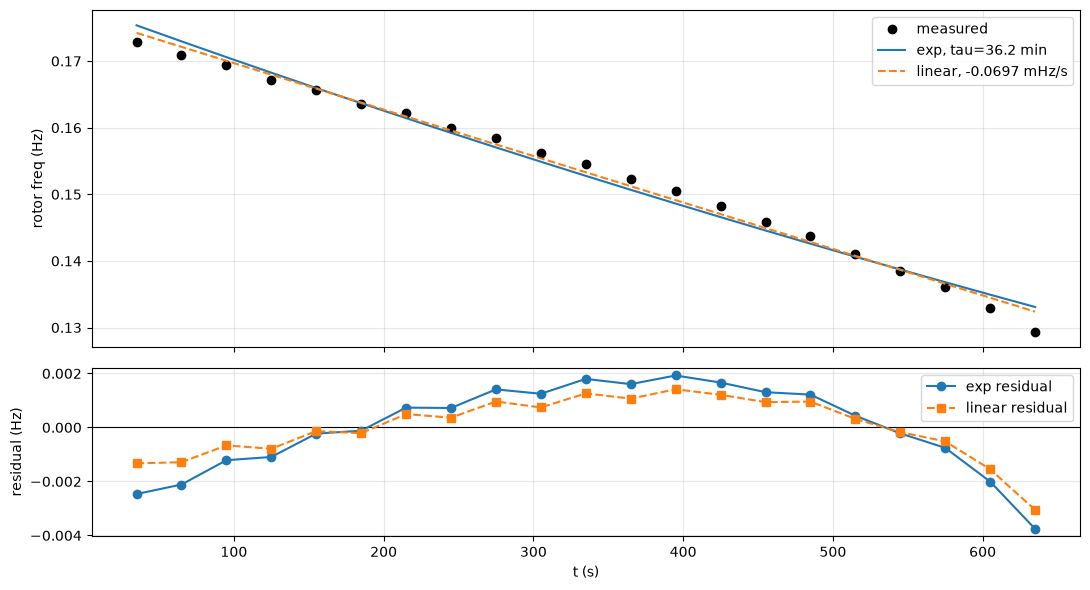

In [6]:
tg, fg = T[good], FR[good]
pe = np.polyfit(tg, np.log(fg), 1); tau = -1/pe[0]; f0e = np.exp(pe[1])
fit_e = f0e*np.exp(-tg/tau)
pl = np.polyfit(tg, fg, 1); fit_l = np.polyval(pl, tg)
rms_e = np.sqrt(np.mean((fg-fit_e)**2)); rms_l = np.sqrt(np.mean((fg-fit_l)**2))

print(f'EXPONENTIAL  tau = {tau/60:6.1f} min   f0 = {f0e:.5f} Hz   residual {rms_e:.6f} Hz')
print(f'LINEAR       {pl[0]*1000:7.4f} mHz/s   f0 = {pl[1]:.5f} Hz   residual {rms_l:.6f} Hz')
print(f'\nratio of residuals (linear/exponential) = {rms_l/rms_e:.3f}')
print('  < 1 favours linear (constant torque); > 1 favours exponential (viscous)')

fig, ax = plt.subplots(2, 1, figsize=(11, 6), sharex=True,
                       gridspec_kw={'height_ratios':[2,1]})
ax[0].plot(tg, fg, 'ko', label='measured')
ax[0].plot(tg, fit_e, '-',  label=f'exp, tau={tau/60:.1f} min')
ax[0].plot(tg, fit_l, '--', label=f'linear, {pl[0]*1000:.4f} mHz/s')
ax[0].set_ylabel('rotor freq (Hz)'); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].axhline(0, color='k', lw=.8)
ax[1].plot(tg, fg-fit_e, 'o-',  label='exp residual')
ax[1].plot(tg, fg-fit_l, 's--', label='linear residual')
ax[1].set_ylabel('residual (Hz)'); ax[1].set_xlabel('t (s)'); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

## 6. Can these models even be distinguished here?

Over a small fractional decay, `exp(-t/τ) ≈ 1 - t/τ` — the two models are **identical to first order**. So before believing either, ask how much decay we actually have, and what would be needed.

Rule of thumb: the curvature that separates them is second order, `(t/τ)²/2`. It only exceeds the scatter once the decay is a substantial fraction of `f0`.

In [7]:
frac = 1 - fg.min()/fg.max()
curv = 0.5*frac**2*fg.max()      # size of the exp-vs-linear difference, Hz
print(f'fractional decay observed : {100*frac:.1f}%')
print(f'exp-vs-linear difference  : ~{curv:.5f} Hz')
print(f'residual scatter          : ~{min(rms_e,rms_l):.5f} Hz')
print(f'\nseparation ratio = {curv/min(rms_e,rms_l):.1f}  (need >> 1 to distinguish)')
if curv/min(rms_e,rms_l) < 3:
    print('\n*** NOT DISTINGUISHABLE with this data. Do not quote one over the other. ***')
    for target in (0.5, 0.7, 0.9):
        need = np.sqrt(2*3*min(rms_e,rms_l)/fg.max())
        print(f'  need roughly {100*need:.0f}% decay for a 3-sigma separation')
        break

fractional decay observed : 25.2%
exp-vs-linear difference  : ~0.00549 Hz
residual scatter          : ~0.00112 Hz

separation ratio = 4.9  (need >> 1 to distinguish)


## 7. What it means for spin-up

Propagate whichever model into the drag torque, and hence the top speed the stator could hold.

**Caveat carried through everything below:** `I = 1.88e-11 kg·m²` is *assumed and never measured*, and both drag torque and ramp rate scale linearly with it. And the stator torque figure is from the m=8 table, whose applicability is itself unresolved (see `hv_amp_dc_investigation.md`).

In [8]:
I = 1.88e-11          # ASSUMED
TAU_STATOR = 8.8e-13  # N m, 85.8 V, 0.37 mm gap, m=8 table

print('IF VISCOUS:')
wmax = TAU_STATOR*tau/I
print(f'  terminal speed = tau_stator * tau_decay / I / 2pi = {wmax/2/np.pi:.1f} Hz')
for fr_ in (5, 10, 15, 19):
    print(f'    drag at {fr_:2d} Hz = {I*2*np.pi*fr_/tau:.2e} N m '
          f'({I*2*np.pi*fr_/tau/TAU_STATOR:.2f}x stator)')
print('\nIF CONSTANT TORQUE:')
dt = I*2*np.pi*abs(pl[0])
print(f'  drag torque = {dt:.2e} N m  ({dt/TAU_STATOR:.4f}x stator), speed-independent')
print('  -> no terminal speed limit from drag')
print(f'\nRamp 0 -> 15 Hz at 50% margin: '
      f'{15/(0.5*TAU_STATOR/(2*np.pi*I))/60:.0f} min')
print('\nFor comparison, Nature Comms s41467-026-75188-1 (optimised, similar rotor):')
print('  3.85 uHz damping, 10 h free spin, 930 RPM = 15.5 Hz')
print(f'  this rotor: tau = {tau/60:.0f} min -- roughly 3 orders of magnitude worse.')
print('  Configuration here has NO TILT STAGE and unoptimised tilt (see 07-27 log).')

IF VISCOUS:
  terminal speed = tau_stator * tau_decay / I / 2pi = 16.2 Hz
    drag at  5 Hz = 2.72e-13 N m (0.31x stator)
    drag at 10 Hz = 5.43e-13 N m (0.62x stator)
    drag at 15 Hz = 8.15e-13 N m (0.93x stator)
    drag at 19 Hz = 1.03e-12 N m (1.17x stator)

IF CONSTANT TORQUE:
  drag torque = 8.24e-15 N m  (0.0094x stator), speed-independent
  -> no terminal speed limit from drag

Ramp 0 -> 15 Hz at 50% margin: 67 min

For comparison, Nature Comms s41467-026-75188-1 (optimised, similar rotor):
  3.85 uHz damping, 10 h free spin, 930 RPM = 15.5 Hz
  this rotor: tau = 36 min -- roughly 3 orders of magnitude worse.
  Configuration here has NO TILT STAGE and unoptimised tilt (see 07-27 log).


## Conclusions

*(fill in after running — the notebook prints the separation ratio in §6, which is the thing that decides whether the damping number can be trusted at all)*

**To settle it properly:** one long spindown from a higher speed. The two models diverge as the square of the fractional decay, so getting the rotor to 1–2 Hz and letting it coast for an hour would separate them decisively where 0.17 Hz over 10 minutes cannot.